# Polar cut efficiency

In [54]:
import numpy as np
import matplotlib.pyplot as plt


from glob import glob

import matplotlib
# Set default figuresize and font size and labelsize for plots
# plt.rcParams['figure.figsize'] = (15, 12)
plt.rcParams['font.size'] = 25
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [55]:
def calculate_PAO_spectrum(e_eV):
    """
    Calculate the CR flux measured by PAO in 10 ** 17 eV < E < 10 ** 20 eV
    with the SD-750 and SD-1500.
    The formula of the spectrum is Equation (13) of
    Abreu et al., Eur. Phys. J. C 81, 966 (2021)
    (https://doi.org/10.1140/epjc/s10052-021-09700-w)
    """


    j_0 = 1.309e-18 # km^-2 yr^-1 sr^-1 eV^-1
    e_0 = 10 ** 18.5 # eV
    omega_01, omega_12, omega_23, omega_34 = 0.43, 0.05, 0.05, 0.05
    g_0, g_1, g_2, g_3, g_4 = 2.64, 3.298, 2.52, 3.08, 5.2
    e_01, e_12, e_23, e_34 = 1.24e17, 4.9e18, 1.4e19, 4.7e19 # eV

    j = j_0 * (e_eV/e_0) ** (-g_0) \
            * (1 + (e_eV/e_01) ** (1/omega_01)) ** ((g_0-g_1) * omega_01) \
            * (1 + (e_eV/e_12) ** (1/omega_12)) ** ((g_1-g_2) * omega_12) \
            * (1 + (e_eV/e_23) ** (1/omega_23)) ** ((g_2-g_3) * omega_23) \
            * (1 + (e_eV/e_34) ** (1/omega_34)) ** ((g_3-g_4) * omega_34) \
            / (1 + (e_0/e_01)  ** (1/omega_01)) ** ((g_0-g_1) * omega_01) \
            / (1 + (e_0/e_12)  ** (1/omega_12)) ** ((g_1-g_2) * omega_12) \
            / (1 + (e_0/e_23)  ** (1/omega_23)) ** ((g_2-g_3) * omega_23) \
            / (1 + (e_0/e_34)  ** (1/omega_34)) ** ((g_3-g_4) * omega_34)

    return j

## Extracting

In [56]:
# ZHAiReS simulations
sims_info = np.load("/sps/grand/jlavoisier/code/quantification/polarization_cut/out_files/ZHAiReSGP300AN_event_info.npy")

sims_n_ant_trig = sims_info[0]
sims_theta_list = sims_info[1]
sims_phi_list = sims_info[2]
sims_energy = sims_info[3]

sims_polarization = np.load("/sps/grand/jlavoisier/code/quantification/polarization_cut/out_files/ZHAiReSGP300AN_polar.npy")[0]
print(len(sims_polarization))



# Parasites
parasites_theta_RUN = np.load("/sps/grand/jlavoisier/code/quantification/check_data/data/theta_parasites.npy",
                    allow_pickle=True
                    ).item()
parasites_phi_RUN = np.load("/sps/grand/jlavoisier/code/quantification/check_data/data/phi_parasites.npy",
                    allow_pickle=True
                    ).item()
parasites_polarization_RUN = np.load(f"/sps/grand/jlavoisier/code/quantification/check_data/data/polar_parasites.npy",
                    allow_pickle=True
                    ).item()

RUNs = np.array(list(parasites_polarization_RUN.keys()))


parasites_polarization = np.array([])
parasites_theta = np.array([])
parasites_phi = np.array([])

for run in RUNs:
    parasites_polarization = np.concatenate((parasites_polarization, parasites_polarization_RUN[run]))
    parasites_theta = np.concatenate((parasites_theta, parasites_theta_RUN[run]))
    parasites_phi = np.concatenate((parasites_phi, parasites_phi_RUN[run]))

print(len(parasites_polarization))
print(f"Proportion of parasite polarization values at 2: {len(parasites_polarization[parasites_polarization == 2]) / len(parasites_polarization):.2f}")


44050
5455335
Proportion of parasite polarization values at 2: 0.00


## Cut efficiency

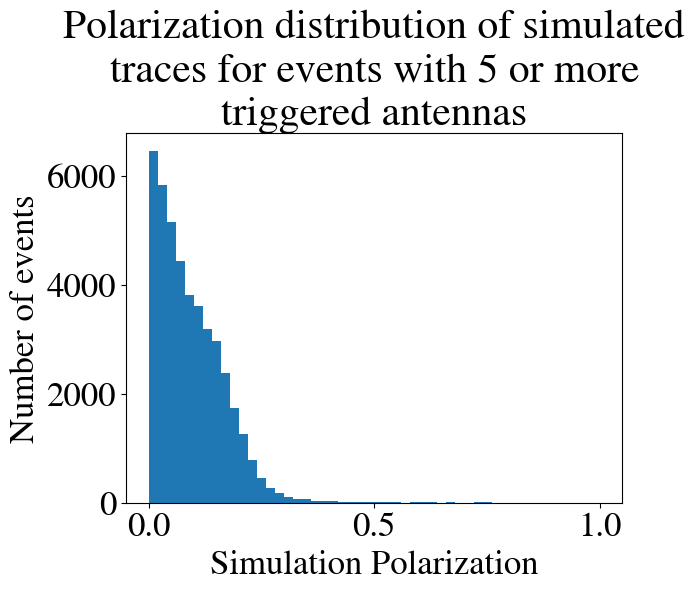

In [57]:
plt.hist(sims_polarization, 
         bins=50, 
         range=(0, 1), 
        #  density=True
         )
plt.xlabel("Simulation Polarization")
plt.ylabel("Number of events")
plt.title("Polarization distribution of simulated traces for events with 5 or more triggered antennas",
          wrap=True)
plt.show()

## Weights in energy per event

In [58]:

# Weights per bin
weights_energy_events = np.zeros(len(sims_energy))
for i in range(len(sims_energy)):
    weights_energy_events[i] = calculate_PAO_spectrum(sims_energy[i] * 1e9) # The weight for the energy bin

weights_energy_events = calculate_PAO_spectrum(sims_energy * 1e9)

weights_zenith_events = np.sin(sims_theta_list * np.pi / 180) * np.cos(sims_theta_list * np.pi / 180) # The weight for the zenith bin

weights_events = weights_energy_events * weights_zenith_events

In [59]:
sims_polar_per_event = np.zeros(len(sims_n_ant_trig))

for i in range(len(sims_n_ant_trig)):
    polar_event_i = sims_polarization[int(np.sum(sims_n_ant_trig[:i])):int(np.sum(sims_n_ant_trig[:i+1]))]
    sims_polar_per_event[i] = np.median(polar_event_i[polar_event_i < 2])
print("Median polarization per event: ", sims_polar_per_event)
print(len(sims_polar_per_event))

Median polarization per event:  [0.12611825 0.06450103 0.06317908 ... 0.16474417 0.03237522 0.07974679]
3496


/pbs/home/j/jlavoisier/.local/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/pbs/home/j/jlavoisier/.local/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


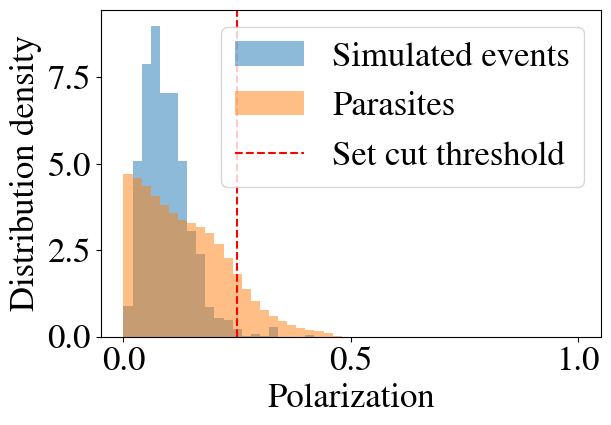

In [60]:
# plt.figure(figsize=(8, 8))
plt.hist(sims_polar_per_event, 
         bins=50, 
         range=(0, 1), 
         density=True,
         weights=weights_events,
         label="Simulated events",
            alpha=0.5
         )
plt.hist(parasites_polarization,
         bins=50,
         range=(0, 1),
         density=True,
         label="Parasites",
         alpha=0.5
         )

plt.xlabel("Polarization")
plt.ylabel("Distribution density")
# plt.title("Median Polarization distribution of traces of simulated events with 5 or more triggered antennas",
#           wrap=True,
#         #   fontsize=16
#           )
plt.axvline(x=0.25, 
            color='red', 
            linestyle='--', 
            label='Set cut threshold'
            )

plt.legend()
plt.tight_layout()
# plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/polarization_cut/plots/polarization_per_event.png")
plt.show()

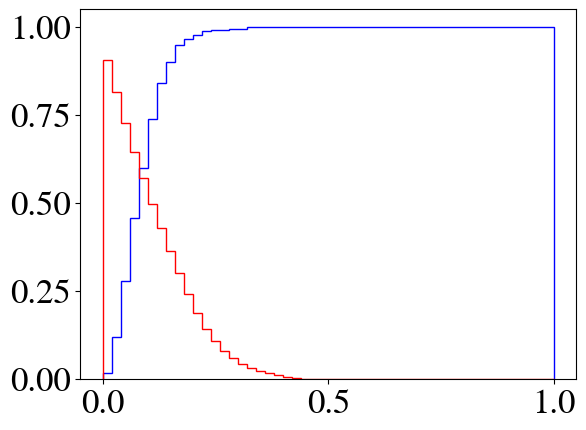

In [61]:

counts_sims, bins_i = np.histogram(sims_polar_per_event, 
                                  bins=50,
                                  range=(0,1),
                                  weights=weights_events
                                  )

bin_width = bins_i[1] - bins_i[0]
normalized_distrib_sims = counts_sims / (np.sum(weights_events) * bin_width)
# normalized_distrib_sims = counts_sims / (len(sims_polar_per_event) * bin_width)

cumulative_counts_sims= np.cumsum(normalized_distrib_sims)
normalized_cumulative_counts_sims = cumulative_counts_sims / cumulative_counts_sims[-1]

# ---------------------------------------

counts_parasites, bins_i = np.histogram(parasites_polarization, 
                                  bins=50,
                                  range=(0,1)
                                  )

normalized_distrib_parasites = counts_parasites / (len(parasites_polarization) * bin_width)

cumulative_counts_parasites= np.cumsum(normalized_distrib_parasites)
normalized_cumulative_counts_parasites = cumulative_counts_parasites / cumulative_counts_parasites[-1]

# --------- plot ----------------
plt.stairs(normalized_cumulative_counts_sims, 
                 bins_i, 
                 label='Sims', 
                 color='blue'
                 )
plt.stairs(1-normalized_cumulative_counts_parasites, 
                 bins_i, 
                 label='Parasites', 
                 color='red'
                 )

(array([5.05529636e+00, 4.95124086e+00, 4.73374629e+00, 4.43191430e+00,
        4.09629463e+00, 3.74628455e+00, 3.42740404e+00, 3.14070718e+00,
        2.91335931e+00, 2.71156130e+00, 2.51017575e+00, 2.29250932e+00,
        2.02119967e+00, 1.74046062e+00, 1.47259962e+00, 1.22476604e+00,
        1.01170547e+00, 8.43408693e-01, 7.03205303e-01, 5.92344144e-01,
        4.96022341e-01, 4.12807727e-01, 3.46252077e-01, 3.08935541e-01,
        2.69487942e-01, 2.21447343e-01, 1.52164847e-01, 1.20233258e-01,
        1.02967056e-01, 8.76027722e-02, 7.14593892e-02, 6.22820651e-02,
        5.09163902e-02, 4.28045981e-02, 3.31918952e-02, 2.39343697e-02,
        2.04742550e-02, 1.69110243e-02, 1.51809669e-02, 1.25916096e-02,
        1.24082922e-02, 1.28551282e-02, 1.35883976e-02, 1.45737283e-02,
        1.35196536e-02, 1.24999509e-02, 1.00824535e-02, 8.20345081e-03,
        5.35057476e-03, 2.93307738e-03]),
 array([1.41714189e-08, 1.76697738e-02, 3.53395334e-02, 5.30092930e-02,
        7.06790526e-02

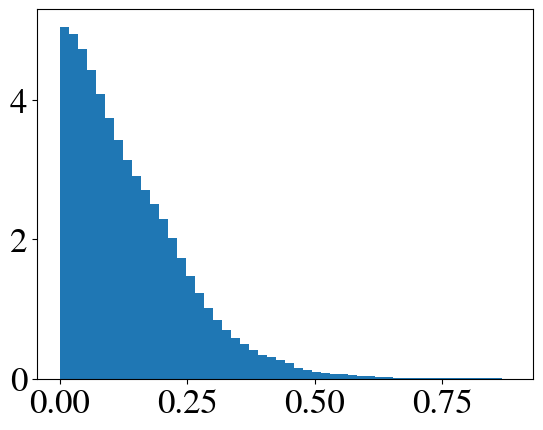

In [62]:
plt.hist(np.abs(parasites_polarization), 
         bins=50, 
        #  range=(0, 1), 
         density=True, label="Parasites")

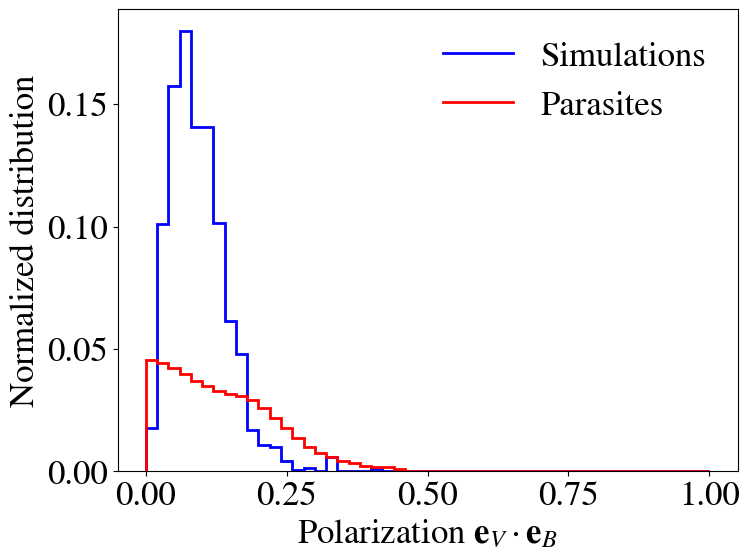

Porportion of parasite polarization values at 2: 0.00


In [63]:
hist_parasites, bins_i = np.histogram(parasites_polarization, 
                                  bins=50,
                                  range=(0,1)
                                  )
hist_sims, bins_i = np.histogram(sims_polar_per_event, 
                                  bins=50,
                                  range=(0,1),
                                  weights=weights_events
                                  )

norm_hist_parasites = hist_parasites / (len(parasites_polarization))
norm_hist_sims = hist_sims / (np.sum(weights_events))

plt.figure(figsize=(8,6))
plt.stairs(norm_hist_sims, 
            bins_i, 
            label='Simulations', 
            color='blue',
            linewidth=2
            )

# plt.hist(sims_polar_per_event, 
#          bins=50, 
#          range=(0, 1), 
#          density=True,
#          weights=weights_events,
#          label="Simulated events",
#             alpha=0.5
#          )

plt.stairs(norm_hist_parasites, 
           bins_i, 
           label='Parasites', 
           color='red',
           linewidth=2
           )
plt.legend(
        #    fontsize=20,
           frameon=False
           )
plt.xlabel(r"Polarization ${\bf e}_V\cdot{\bf e}_B$",
        #    fontsize=20
           )
plt.ylabel("Normalized distribution",
        #    fontsize=20
           )
# plt.tight_layout()
plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/polarization_distrib.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )
plt.show()

print(f"Porportion of parasite polarization values at 2: {len(parasites_polarization[parasites_polarization == 2]) / len(parasites_polarization):.2f}")

[[0.         0.01772751 0.90578653]
 [0.0137931  0.01772751 0.90578653]
 [0.02758621 0.11903798 0.81421333]
 [0.04137931 0.2764649  0.7270828 ]
 [0.05517241 0.2764649  0.7270828 ]
 [0.06896552 0.45640227 0.64546675]
 [0.08275862 0.5973414  0.56923518]
 [0.09655172 0.5973414  0.56923518]
 [0.11034483 0.73833915 0.49743078]
 [0.12413793 0.83984232 0.42967333]
 [0.13793103 0.83984232 0.42967333]
 [0.15172414 0.90115297 0.36413514]
 [0.16551724 0.94910768 0.30093638]
 [0.17931034 0.94910768 0.30093638]
 [0.19310345 0.96605204 0.24117912]
 [0.20689655 0.97692979 0.18770508]
 [0.22068966 0.98672216 0.14248784]
 [0.23448276 0.98672216 0.14248784]
 [0.24827586 0.9911273  0.10628329]
 [0.26206897 0.99169861 0.07853018]
 [0.27586207 0.99169861 0.07853018]
 [0.28965517 0.99298726 0.05780974]
 [0.30344828 0.99332308 0.04224513]
 [0.31724138 0.99332308 0.04224513]
 [0.33103448 0.99917704 0.03053889]
 [0.34482759 0.99917704 0.02164034]
 [0.35862069 0.99917704 0.02164034]
 [0.37241379 0.99917704 0.01

/scratch/users/j/jlavoisier/ipykernel_455081/2481905127.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=r"$\ell_{\rm CR,polar}$"+f"<{1-x[first_at_99]:.2f}" + r" for ${e}_V \cdot {e}_B$"+ f"={test_cut_parameter[first_at_99]:.2f}",


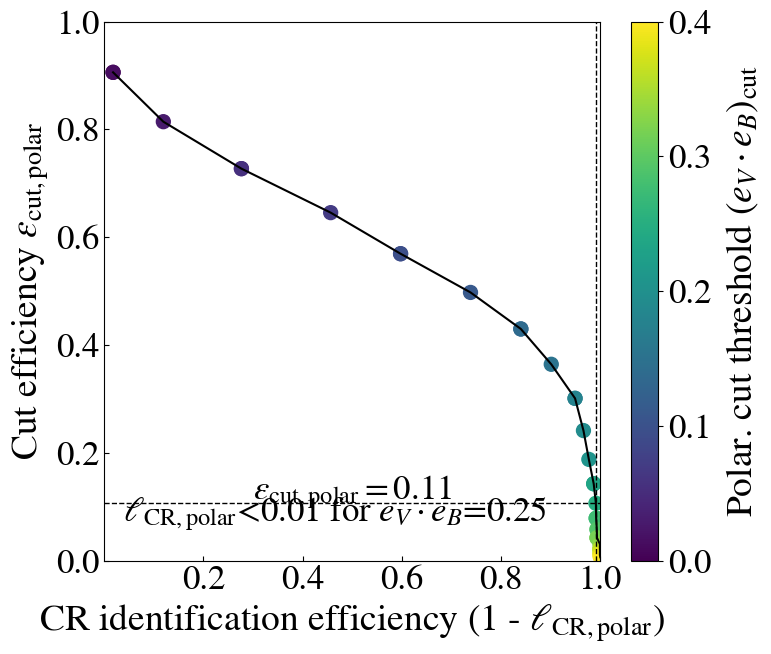

In [64]:
test_cut_parameter = np.linspace(0, .4, 30)

mask_parameter_in_bin = np.digitize(test_cut_parameter, bins_i) -1

fig = plt.figure(figsize=(8, 7))
x = normalized_cumulative_counts_sims[mask_parameter_in_bin]
y =1-normalized_cumulative_counts_parasites[mask_parameter_in_bin]
plt.plot(x,
         y,
         color='black')
plt.scatter(x,
            y,
            c=test_cut_parameter,
            s=100)
plt.xlabel("CR identification efficiency " + r"(1 - $\ell_{\rm CR,polar})$",
            # r"$\varepsilon_{\text{signal}}$",
           fontsize=27
           )
plt.ylabel(r"Cut efficiency $\varepsilon_{\rm cut, polar}$",
            # r"$1 - \varepsilon_{\text{background}}$",
           fontsize=27
           )
plt.tick_params(axis='x', 
                    labelsize=22,
                    direction="in"
                    )
plt.tick_params(axis='y', 
                    labelsize=22,
                    direction="in"
                    )


# ax[i].legend(loc=4,
#              fontsize=15)

cbar = plt.colorbar() 
cbar.ax.tick_params(labelsize=25)
cbar.set_label(r"Polar. cut threshold $({e}_V \cdot {e}_B)_{\rm cut}$", 
               rotation=90, 
               fontsize=27, 
               labelpad=+10
               )


print(np.array([test_cut_parameter, x ,y]).T)

first_at_99 = np.where(x >= 0.99)[0][0]
print(f"First point at 99% efficiency: {test_cut_parameter[first_at_99]:.2f}")


plt.plot(np.zeros(20) + x[first_at_99],
        np.linspace(0, 1, 20),
        color='black',
        linewidth=1,
        linestyle='--',
        )

plt.plot(
        np.linspace(0, 1, 20),
        np.zeros(20) + y[first_at_99],
        color='black',
        linewidth=1,
        linestyle='--',
        )


plt.ylim(0, 1)
# plt.yscale('log')
plt.xlim(0, 1)
plt.xticks(np.array([0.2, 0.4, 0.6, 0.8, 1]),
           fontsize=25
           )
plt.yticks(np.array([0, 0.2, 0.4, 0.6, 0.8, 1, 
                    #  y[first_at_99]
                     ]),
           fontsize=25
           )


plt.annotate(r"$\varepsilon_{\rm cut, polar}=$" + f"{y[first_at_99]:.2f}",
             xy=(0.95, 1.0),
             xytext=(0.3, y[first_at_99]*1.09),
             fontsize=25
             )

# plt.annotate(r"$\varepsilon_{\text{signal}}$"+f"={x[first_at_99]:.2f}" + r"for ${e}_V \cdot {e}_B$"+ f" at {test_cut_parameter[first_at_99]:.2f}",
#              xy=(0.99, 1.0),
#              xytext=(0.94, .65),
#              fontsize=15,
#              rotation=90)


plt.legend(title=r"$\ell_{\rm CR,polar}$"+f"<{1-x[first_at_99]:.2f}" + r" for ${e}_V \cdot {e}_B$"+ f"={test_cut_parameter[first_at_99]:.2f}",
           loc='lower left',
           frameon=False,
           fontsize=15
           )

# inset = plt.axes([0.2, 0.32, 0.45, 0.33])
# inset = plt.axes([0.33, 0.53, 0.4, 0.3])
# inset.stairs(
#             normalized_distrib_sims, 
#             bins_i, 
#             label='Sim', 
#             color='blue')
# inset.stairs(
#            normalized_distrib_parasites, 
#            bins_i, 
#            label='Data', 
#            color='red')
# inset.tick_params(axis='both', 
#                     labelsize=20,
#                     direction="in"
#                     )
# inset.legend(fontsize=20,
#              frameon=False)
# inset.set_yticks([])
# inset.set_ylabel("Proba. distrib.",
#                  fontsize=20)
# inset.set_xlabel(r"${e}_V \cdot {e}_B$",
#                      fontsize=20)

plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/polarization_efficiency.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )
plt.show()

Proportion of events with zenith angle between 60 and 88 degrees: 0.44


Cut efficiency for loss rate < 1%: 4.96%
Value of cut parameter for loss rate < 1%: 0.26


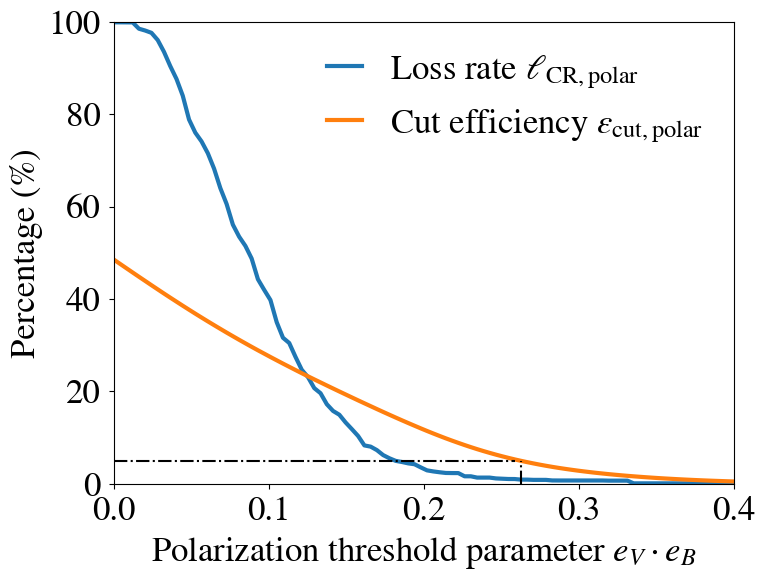

In [65]:
test_cut_parameter = np.linspace(0, .4, 100)
# print(parasites_theta)
mask_zenith = (parasites_theta > 60*np.pi/180) & (parasites_theta < 88*np.pi/180)
print(f"Proportion of events with zenith angle between 60 and 88 degrees: {np.sum(mask_zenith)/len(mask_zenith):.2f}")

x = np.array([np.sum(weights_events[sims_polar_per_event >= cut]) / np.sum(weights_events) for cut in test_cut_parameter])
y = np.array([len(parasites_polarization[parasites_polarization >= cut]) / len(parasites_polarization) for cut in test_cut_parameter])
# z = y + np.array([len(parasites_polarization[parasites_polarization < cut]) / len(parasites_polarization) for cut in test_cut_parameter])

fig = plt.figure(figsize=(8, 6))
plt.plot(test_cut_parameter, 
         100 * x, 
         label=r"Loss rate $\ell_{\rm CR,polar}$",
         linewidth=3
         )


plt.plot(test_cut_parameter, 
         100 * y, 
         label=r"Cut efficiency $\epsilon_{\rm cut, polar}$",
         linewidth=3
         )

# plt.plot(test_cut_parameter,
#          100 * z,)

index_first_99 = np.where(x < 0.01)[0][0]
plt.plot(test_cut_parameter[index_first_99]+np.zeros(50),
         np.linspace(0, 100*y[index_first_99], 50),
         color='black',
         linestyle='-.',
         )
plt.plot(test_cut_parameter[:index_first_99],
         100*y[index_first_99]+np.zeros(len(test_cut_parameter[:index_first_99])),
         linestyle='-.',
         color='black',
         )

print(f"Cut efficiency for loss rate < 1%: {100*y[index_first_99]:.2f}%")
print(f"Value of cut parameter for loss rate < 1%: {test_cut_parameter[index_first_99]:.2f}")



plt.xlabel(r"Polarization threshold parameter ${e}_V \cdot {e}_B$",
            # fontsize=22
            )
plt.xlim(0, 0.4)
plt.ylabel("Percentage (%)", 
        #    fontsize=22
           )
plt.ylim(0, 100)
plt.legend(
        #    fontsize=18,
           handlelength=1,
           frameon=False
           )
plt.tick_params(axis='both', 
                    # labelsize=20,
                    # direction="in"
                pad=6
                    )
plt.show()

## Arrival direction of events dependancy

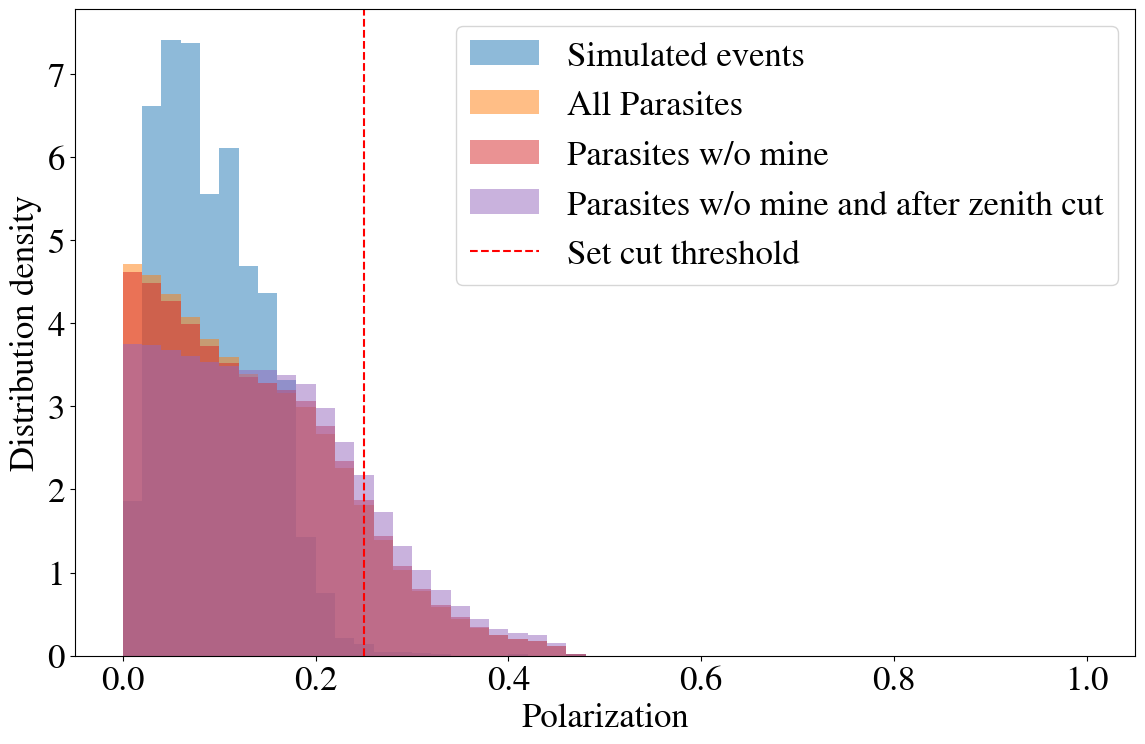

In [66]:
# Polar Histogram for events passing through zenith cut
fig = plt.figure(figsize=(12, 8))
plt.hist(sims_polar_per_event,
         bins=50,
         range=(0, 1),
         density=True,
         label="Simulated events",
         alpha=0.5
         )
plt.hist(parasites_polarization,
         bins=50,
         range=(0, 1),
         density=True,
         label="All Parasites",
         alpha=0.5
         )

# plt.hist(parasites_polarization[mask_zenith],
#          bins=50,
#          range=(0, 1),
#          density=True,
#          label="Parasites with zenith cut",
#          alpha=0.5
#          )

mask_mine = (parasites_phi > 280*np.pi/180) & (parasites_phi < 315*np.pi/180)

plt.hist(parasites_polarization[~mask_mine],
         bins=50,
         range=(0, 1),
         density=True,
         label="Parasites w/o mine",
         color='tab:red',
         alpha=0.5
         )

plt.hist(parasites_polarization[np.logical_and(mask_zenith, ~mask_mine)],
         bins=50,
         range=(0, 1),
         density=True,
         label="Parasites w/o mine and after zenith cut",
         color='tab:purple',
         alpha=0.5
         )

plt.xlabel("Polarization")
plt.ylabel("Distribution density")
# plt.title("Median Polarization distribution of traces of simulated events with 5 or more triggered antennas",
#           wrap=True,
#         #   fontsize=16
#           )
plt.axvline(x=0.25, 
            color='red', 
            linestyle='--', 
            label='Set cut threshold'
            )

plt.legend()
plt.tight_layout()
# plt.savefig(f"/pbs/home/j/jlavoisier/pipeline_lab/polarization_cut/plots/polarization_per_event.png")
plt.show()

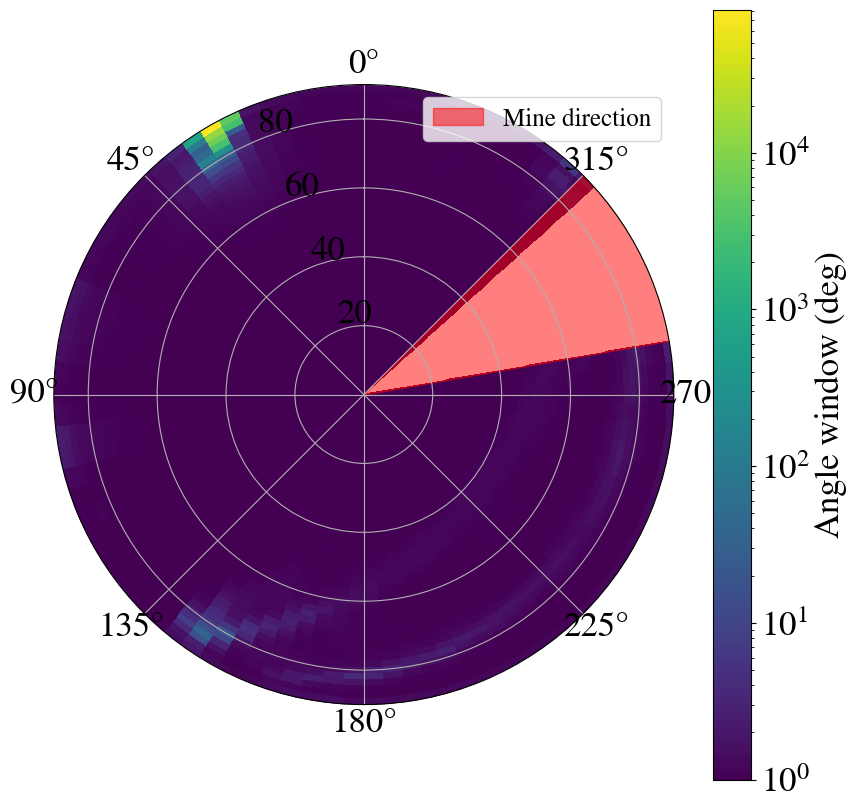

In [67]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='polar')

counts_2d = np.histogram2d(parasites_phi[~mask_mine],
                      parasites_theta[~mask_mine]*180/np.pi,
                      bins=[90, 50],
                      range=[[0, 2*np.pi], [0, 90]]
                      )

plt.hist2d(parasites_phi[~mask_mine],
           parasites_theta[~mask_mine]*180/np.pi,
           bins=[90, 50],
           range=[[0, 2*np.pi], [0, 90]],
           cmap='viridis',
           cmin=1,
           )
# ax.scatter(parasites_phi, 
#                parasites_theta*180/np.pi,
#                c=parasites_polarization,
#                cmap='viridis',
#                alpha=1, 
#                s=5
#                )

plt.fill_between(x=np.linspace(280*np.pi/180, 315*np.pi/180, 100),
                 y1=0, y2=90,
                 alpha=0.5,
                 color='red',
                 label="Mine direction"
                 )


ax1 = plt.gca()
# Create a ScalarMappable for the colorbar
norm = matplotlib.colors.LogNorm(vmin=1, vmax=counts_2d[0].max()) 
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])  # This is required for the colorbar to work

fig = plt.gcf()
fig.colorbar(sm, ax=ax1, label="Angle window (deg)")

ax.tick_params(axis='both', 
                  labelsize=25)

ax.set_theta_zero_location("N")
ax.set_ylim(0,90)

plt.legend(fontsize=18)
plt.show()

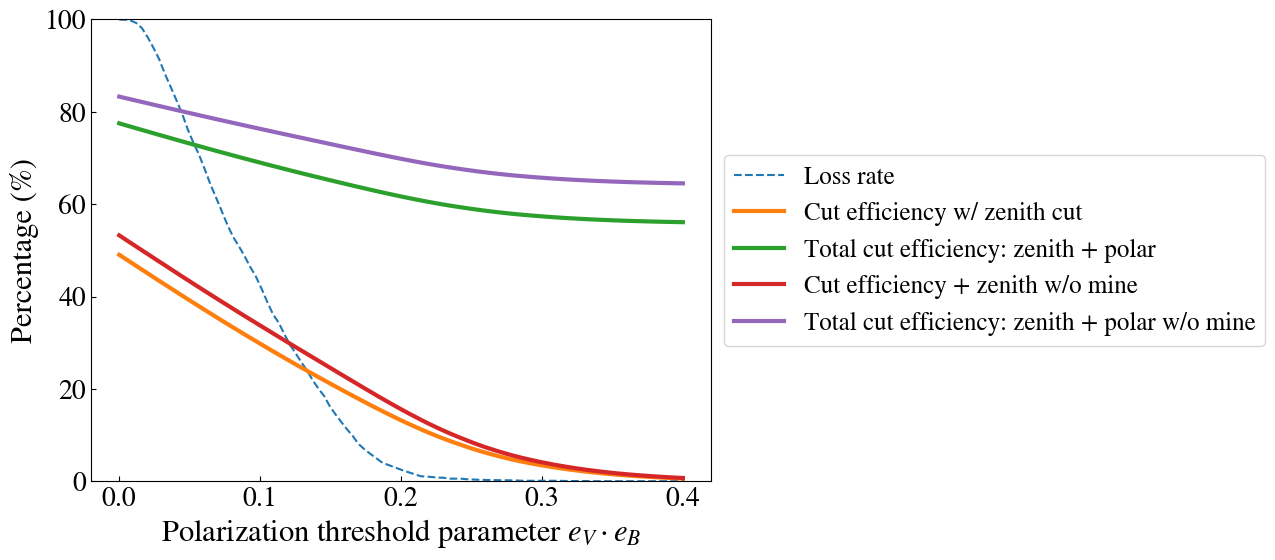

In [68]:


x = np.array([np.sum(sims_polar_per_event > cut) / len(sims_polar_per_event) for cut in test_cut_parameter])
y = np.array([np.sum(parasites_polarization[mask_zenith] > cut) / len(parasites_polarization[mask_zenith]) for cut in test_cut_parameter])
y_full = np.array([(np.sum(parasites_polarization[mask_zenith] > cut) + np.sum(~mask_zenith))/ len(parasites_polarization) for cut in test_cut_parameter])

y2 = np.array([np.sum(parasites_polarization[np.logical_and(mask_zenith, ~mask_mine)] > cut) / len(parasites_polarization[np.logical_and(mask_zenith, ~mask_mine)]) for cut in test_cut_parameter])
y_full_mine = np.array([(np.sum(parasites_polarization[np.logical_and(mask_zenith, ~mask_mine)] > cut) + np.sum(np.logical_or(~mask_zenith, mask_mine)))/ len(parasites_polarization) for cut in test_cut_parameter])

fig = plt.figure(figsize=(8, 6))
plt.plot(test_cut_parameter, 
         100*x, 
         label=r"Loss rate",
         linestyle='--',
         )
plt.plot(test_cut_parameter, 
         100*y, 
         label=r"Cut efficiency w/ zenith cut",
        #  marker='o',
        linewidth=3
         )
plt.plot(test_cut_parameter, 
         100*y_full, 
         label=r"Total cut efficiency: zenith + polar",
        #  marker='o',
         linewidth=3
         )


plt.plot(test_cut_parameter, 
         100*y2,
         label=r"Cut efficiency + zenith w/o mine",
        #  marker='o',
         linewidth=3
         )

plt.plot(test_cut_parameter, 
         100*y_full_mine, 
         label=r"Total cut efficiency: zenith + polar w/o mine",
        #  marker='o',
         linewidth=3
         )
plt.ylim(0,100)
plt.xlabel(r"Polarization threshold parameter ${e}_V \cdot {e}_B$",
            fontsize=22)
plt.ylabel("Percentage (%)", 
           fontsize=22)
plt.legend(fontsize=18, 
           loc='center left', 
           bbox_to_anchor=(1, 0.5)
           )
plt.tick_params(axis='both', 
                    labelsize=20,
                    direction="in"
                    )
plt.show()